# NACA Airfoil Surrogate Model — Machine Learning Model

This notebook trains a Random Forest surrogate model to predict aerodynamic 
coefficients (Cl, Cd) from NACA 4-digit airfoil geometry and flight conditions.
The goal is to replace expensive XFoil simulations with a fast ML prediction.

**Inputs:** m, p, t (NACA digits), Reynolds number, angle of attack  
**Outputs:** Lift coefficient (Cl), Drag coefficient (Cd)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('../data/xfoil_dataset.csv', dtype={'naca': str})
df['naca'] = df['naca'].str.zfill(4)


   naca  m  p  t
0  0006  0  0  6
1  0006  0  0  6
2  0006  0  0  6
3  0006  0  0  6
4  0006  0  0  6
5  0006  0  0  6
6  0006  0  0  6
7  0006  0  0  6
8  0006  0  0  6
9  0006  0  0  6

Features ready. Shape: (20113, 9)


## Feature Engineering
The NACA 4-digit code is decomposed into three physically meaningful parameters:
- **m** — maximum camber as % of chord
- **p** — chordwise position of maximum camber
- **t** — maximum thickness as % of chord

These replace the raw string code with numeric values the model can learn from.

In [ ]:

# Extract NACA digits as separate numeric features
df['m'] = df['naca'].str[0].astype(int)
df['p'] = df['naca'].str[1].astype(int)
df['t'] = df['naca'].str[2:].astype(int)

print(df[['naca', 'm', 'p', 't']].head(10))
print(f"\nFeatures ready. Shape: {df.shape}")

## Train/Test Split
The dataset is split 80/20 into training and test sets. The test set is held 
out entirely during training and used only for final evaluation — this ensures 
we measure how well the model generalizes to unseen airfoil/condition combinations.

In [5]:
# Define features and targets
features = ['m', 'p', 't', 're', 'aoa']
targets = ['cl', 'cd']

X = df[features]
y = df[targets]

# Split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")
print(f"\nFeatures: {features}")
print(f"Targets:  {targets}")

Training samples: 16090
Test samples:     4023

Features: ['m', 'p', 't', 're', 'aoa']
Targets:  ['cl', 'cd']


## Model Performance
The Random Forest achieves near-perfect Cl prediction (R²=0.9993, MAE=0.011) 
and good Cd prediction (R²=0.87, MAE=0.0016). The weaker Cd performance is 
expected — drag is more sensitive to near-stall flow separation effects that 
are difficult to capture from geometry parameters alone, even for XFoil itself.

In [6]:
# Train Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1  # uses all your CPU cores
)

rf.fit(X_train, y_train)
print("Model trained.")

# Evaluate
y_pred = rf.predict(X_test)

for i, target in enumerate(targets):
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
    r2  = r2_score(y_test.iloc[:, i], y_pred[:, i])
    print(f"{target.upper()}  —  MAE: {mae:.4f}  |  R²: {r2:.4f}")

Model trained.
CL  —  MAE: 0.0109  |  R²: 0.9993
CD  —  MAE: 0.0016  |  R²: 0.8703


## Predicted vs Actual
Cl predictions lie tightly along the perfect prediction line across the full 
range. Cd shows more scatter at high values (Cd > 0.05), corresponding to 
high angle of attack conditions near stall — consistent with the known 
limitations of panel methods in separated flow regimes.

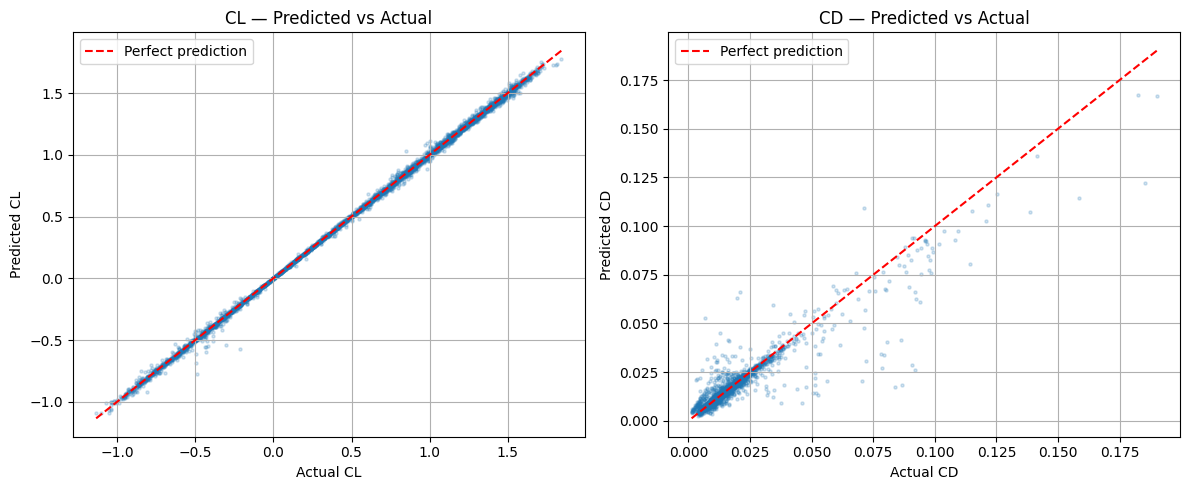

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, target in enumerate(targets):
    actual = y_test.iloc[:, i]
    predicted = y_pred[:, i]
    
    axes[i].scatter(actual, predicted, alpha=0.2, s=5)
    
    # Perfect prediction line
    lims = [actual.min(), actual.max()]
    axes[i].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    
    axes[i].set_xlabel(f'Actual {target.upper()}')
    axes[i].set_ylabel(f'Predicted {target.upper()}')
    axes[i].set_title(f'{target.upper()} — Predicted vs Actual')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.savefig('../data/predicted_vs_actual.png', dpi=150)
plt.show()

## Feature Importance
Angle of attack dominates prediction (0.963), which is expected given the 
strong nonlinear relationship between AoA and aerodynamic coefficients. 
Camber magnitude (m) is the second most important geometric parameter (0.030), 
consistent with EDA findings. Camber position (p) shows minimal importance, 
confirming thin airfoil theory predictions. Future work could explore 
interaction features (e.g. m×AoA) to better capture geometry-dependent behavior.

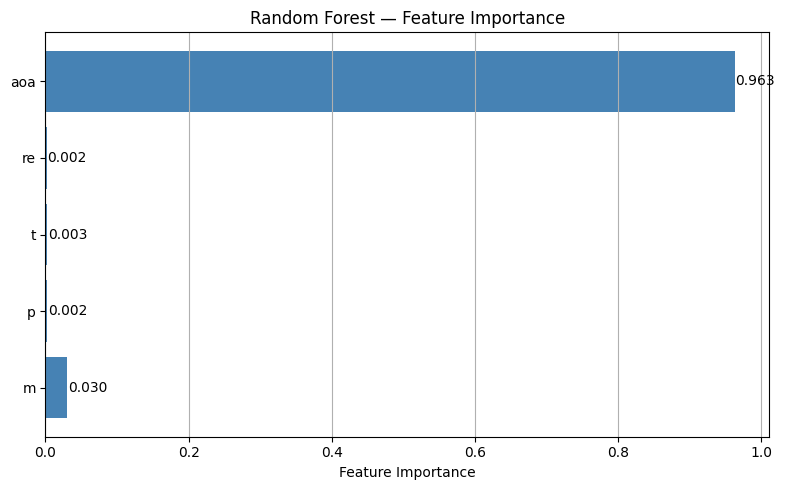

In [8]:
# Feature importance
importances = rf.feature_importances_
feat_names = features

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(feat_names, importances, color='steelblue')
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest — Feature Importance')
ax.grid(True, axis='x')

for bar, val in zip(bars, importances):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center')

plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150)
plt.show()

In [9]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(rf, '../models/random_forest.pkl')
print("Model saved to models/random_forest.pkl")

Model saved to models/random_forest.pkl
